In [2]:
import pandas as pd

# URL del archivo CSV en modo raw
url = "https://raw.githubusercontent.com/thiago1251/Proyecto-en-analitica/ddfb002a2e686df07b79ee40d5fc8f63db0c7382/Student%20Depression%20Dataset.csv"

# Leer el archivo CSV
df = pd.read_csv(url)

# Mostrar las primeras filas
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


Columnas categóricas: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Columnas numéricas: ['Age', 'Academic Pressure', 'Work Pressure', 'Work/Study Hours', 'Financial Stress']
Métricas
              precision    recall  f1-score   support

           0      0.809     0.770     0.789      3470
           1      0.842     0.871     0.857      4901

    accuracy                          0.829      8371
   macro avg      0.826     0.820     0.823      8371
weighted avg      0.829     0.829     0.828      8371

AUROC: 0.902848386525834


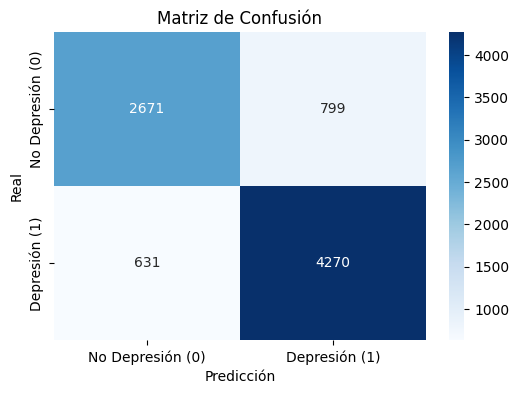

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) Cargar
url = "https://raw.githubusercontent.com/thiago1251/Proyecto-en-analitica/ddfb002a2e686df07b79ee40d5fc8f63db0c7382/Student%20Depression%20Dataset.csv"
df = pd.read_csv(url)

# 2) X, y
y = df["Depression"]        # tu columna objetivo ya existe
X = df.drop(columns=["Profession","Depression", "id", "CGPA", "City", "Study Satisfaction", "Degree", "Job Satisfaction"], errors="ignore")

# 3) Detectar tipos automáticamente
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Si "Sleep Duration" se coló como numérica, fuerzala a categórica:
if "Sleep Duration" in num_cols:
    num_cols.remove("Sleep Duration")
    cat_cols.append("Sleep Duration")

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

# 4) Preprocesamiento
numeric_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pre, num_cols),
        ("cat", categorical_pre, cat_cols)
    ],
    remainder="drop"   # descarta cualquier otra columna
)

# 5) Modelo (puedes cambiar por LogisticRegression o XGBoost/LightGBM si quieres)
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

clf = Pipeline(steps=[
    ("pre", preprocess),
    ("clf", model)
])

# 6) Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 7) Entrenar
clf.fit(X_train, y_train)

# 8) Evaluación

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Métricas")
print(classification_report(y_test, y_pred, digits=3))
print("AUROC:", roc_auc_score(y_test, y_proba))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión (0)", "Depresión (1)"],
            yticklabels=["No Depresión (0)", "Depresión (1)"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

Mejores hiperparámetros: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
Regresión Logística
              precision    recall  f1-score   support

           0      0.793     0.832     0.812      3470
           1      0.877     0.846     0.861      4901

    accuracy                          0.841      8371
   macro avg      0.835     0.839     0.837      8371
weighted avg      0.842     0.841     0.841      8371

AUROC: 0.9187249029340009


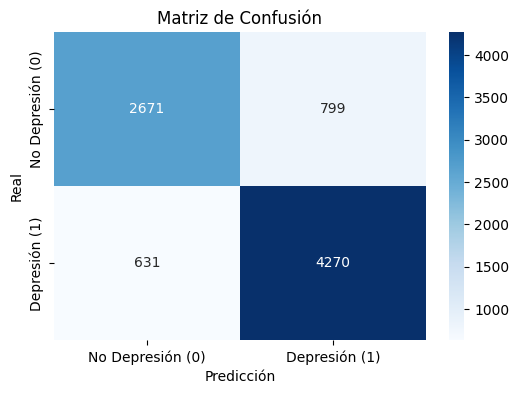

In [4]:
import pandas as pd
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

logreg = Pipeline(steps=[("pre", preprocess),
                         ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

param_grid = {
    "clf__C": [0.1, 1, 5],
    "clf__solver": ["liblinear", "lbfgs"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(logreg, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

best_logreg = gs.best_estimator_
print("Mejores hiperparámetros:", gs.best_params_)

# 6) Evaluación
proba = best_logreg.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Regresión Logística")
print(classification_report(y_test, pred, digits=3))
print("AUROC:", roc_auc_score(y_test, proba))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión (0)", "Depresión (1)"],
            yticklabels=["No Depresión (0)", "Depresión (1)"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
SVM
              precision    recall  f1-score   support

           0      0.831     0.782     0.806      3470
           1      0.852     0.887     0.869      4901

    accuracy                          0.844      8371
   macro avg      0.841     0.835     0.837      8371
weighted avg      0.843     0.844     0.843      8371

AUROC: 0.918791230631636


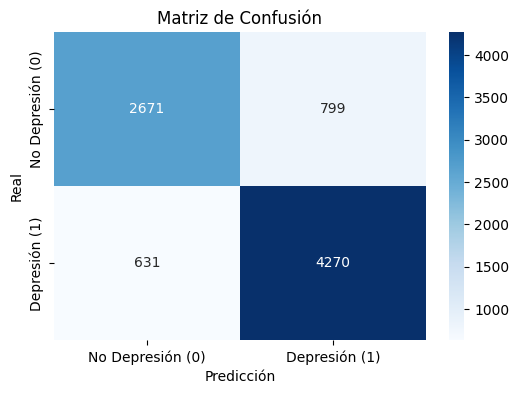

In [5]:
import pandas as pd
from joblib import dump
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

svm_pipe = Pipeline(steps=[("pre", preprocess),
                           ("clf", SVC(probability=True, class_weight="balanced"))])

param_grid = {
    "clf__C": [0.1, 1, 5],
    "clf__kernel": ["linear", "rbf"],
    "clf__gamma": ["scale", "auto"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(svm_pipe, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True, verbose=1)
gs.fit(X_train, y_train)

best_svm = gs.best_estimator_
print("Mejores hiperparámetros:", gs.best_params_)

# 6) Evaluación
proba = best_svm.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("SVM")
print(classification_report(y_test, pred, digits=3))
print("AUROC:", roc_auc_score(y_test, proba))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión (0)", "Depresión (1)"],
            yticklabels=["No Depresión (0)", "Depresión (1)"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [6]:
# 9) Predicción para un nuevo estudiante (pasas un dict con las mismas llaves que X.columns)
def predecir_estudiante(respuestas_dict, thr=0.5):
    sample = pd.DataFrame([respuestas_dict])
    p = float(clf.predict_proba(sample)[:, 1][0])
    return {"probabilidad_depresion": round(p, 4), "prediccion": int(p >= thr)}


# 10) (Opcional) Semáforo por probabilidad
def semaforo(p, t_verde=0.20, t_amarillo=0.40, t_naranja=0.70):
    if p >= t_naranja: return "rojo"
    if p >= t_amarillo: return "naranja"
    if p >= t_verde:    return "amarillo"
    return "verde"

ejemplo = X.iloc[0].to_dict()
res = predecir_estudiante(ejemplo)
res["semaforo"] = semaforo(res["probabilidad_depresion"])
print("Ejemplo:", res)

Ejemplo: {'probabilidad_depresion': 0.8253, 'prediccion': 1, 'semaforo': 'rojo'}


In [7]:
# -*- coding: utf-8 -*-
def semaforo_desde_prob(p, t_verde=0.20, t_amarillo=0.40, t_naranja=0.70):
    """
    p: probabilidad en [0,1]
    Devuelve (nivel, color_hex, etiqueta_color)
    """
    if p >= t_naranja:
        return "rojo",   "#ef4444", "🔴 rojo"
    if p >= t_amarillo:
        return "naranja","#f97316", "🟠 naranja"
    if p >= t_verde:
        return "amarillo","#f59e0b","🟡 amarillo"
    return "verde", "#10b981", "🟢 verde"


def main():
    # Pedir probabilidad
    raw = input("Probabilidad de depresión (ej. 0.37 o 37%): ").strip()
    raw = raw.replace("%", "").replace(",", ".")
    try:
        p = float(raw)
    except ValueError:
        print("❌ Entrada inválida. Escribe un número (ej. 0.37 o 37%).")
        return

    # Si parece porcentaje, normalizar
    if p > 1:
        p = p / 100.0

    if not (0.0 <= p <= 1.0):
        print("La probabilidad debe estar entre 0 y 1 (o 0% y 100%).")
        return

    nivel, color_hex, etiqueta = semaforo_desde_prob(p)

    # Mostrar resultados
    print("Resultado")
    print(f"Probabilidad: {p:.4f} ({p*100:.1f}%)")
    print(f"Nivel: {nivel.upper()}  {etiqueta}")
    print(f"Color (hex): {color_hex}")]

    # (Opcional) decisión binaria con umbral 0.5
    pred = int(p >= 0.5)
    print(f"Predicción binaria (umbral 0.5): {pred}  ->  {'Tiene' if pred==1 else 'No tiene'} depresión (según el umbral)")

if __name__ == "__main__":
    main()



SyntaxError: unmatched ']' (1304572962.py, line 40)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=837422ff-d26d-49e2-bd75-1dfcdfc34958' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>